# Machine Learning (ML)

# 1. Статистика vs ML
## 1. Статистика: Фокусируется на интерпретируемости и поиске зависимостей (почему данные такие?). Важна гипотеза и значимость. Её цель — объяснить. Мы строим модель, чтобы понять взаимосвязи (например, «как уровень образования влияет на доход?»). Нам важны коэффициенты, P-value и доверительные интервалы. Статистика работает с выборками и строгими математическими предположениями.
## 2. ML: Фокусируется на предсказании (каков будет результат?). Главное — точность модели на новых данных, даже если мы не до конца понимаем, то что делается внутри алгоритма. Его цель — предсказать. Нам часто все равно, почему модель приняла решение, если она выдает точный прогноз на новых данных. ML «проглатывает» огромные массивы данных и ищет в них паттерны (закономерности) без жестких априорных гипотез.


## 2. Кластеризация (k-means) и Оценка (СРСП)
Задача:  в СРСП — применить K-Means. Это обучение «без учителя» (unsupervised), где данных много, а меток (правильных ответов) нет.
Основные шаги реализации в Scikit-learn:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Масштабирование (Критично для k-means!)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 2. Модель
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Поскольку «правильных ответов» нет, используют:
## Метод локтя (Elbow Method): Смотрим на график инерции. Где график резко замедляет падение («изгиб локтя»), там оптимальное количество кластеров.
## Силуэтный коэффициент (Silhouette Score): Показывает, насколько объект похож на свой кластер по сравнению с другими. Чем ближе к 1, тем лучше.
## Кластер в машинном обучении — это группа объектов, которые похожи друг на друга по набору признаков и одновременно отличаются от объектов из других групп. Если говорить простыми словами:
Представьте толпу людей. Если вы сгруппируете их по возрасту, то «подростки», «взрослые» и «пенсионеры» — это будут три разных кластера.
Внутри одного кластера объекты должны быть максимально близки (высокое сходство).
Между разными кластерами расстояние должно быть максимально большим (четкое различие).
# Ключевые свойства кластера:
Отсутствие заранее известных меток: Мы не говорим алгоритму: «это группа А». Он сам находит их, анализируя координаты (числа) в данных.
# Центроид: У каждого кластера есть свой «центр масс» — это среднее значение всех признаков объектов, входящих в этот кластер.
# Границы: Они не всегда четкие. Объекты на краях кластера могут быть похожи на соседние группы, и это одна из сложностей задачи.
# Зачем нужны кластеры?
# Маркетинг: Сегментация клиентов (группа «экономных», группа «VIP», группа «активных»).
# Биология: Группировка генов со схожими функциями.
# Безопасность: Выделение кластера «нормального поведения пользователя», чтобы заметить аномалию (взлом).
# Для визуализации кластеров мы обычно используем диаграмму рассеяния (Scatter Plot). Поскольку данные часто имеют много признаков (например, 4 или 10), а экран у нас плоский, мы выбираем два самых важных признака для осей X и Y.
# Код, который наглядно покажет, как алгоритм K-Means разделил данные на группы и где находятся центры этих групп (центроиды).


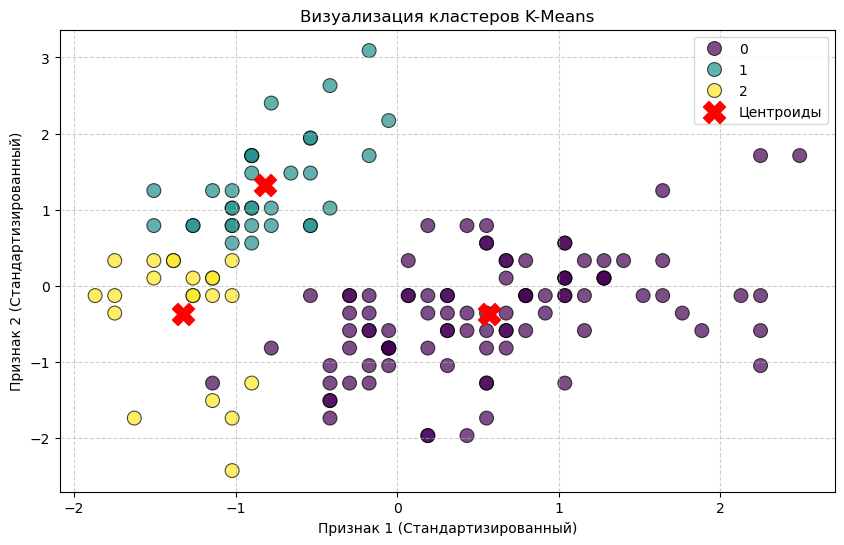

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Используем первые два признака для визуализации (например, длина и ширина чашелистика)
plt.figure(figsize=(10, 6))

# 1. Рисуем точки, раскрашивая их в цвета найденных кластеров
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=clusters, 
                palette='viridis', s=100, alpha=0.7, edgecolors='black')

# 2. Рисуем центроиды (центры кластеров) — помечаем их красными крестиками
centroids = final_kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=250, marker='X', label='Центроиды')

plt.title('Визуализация кластеров K-Means')
plt.xlabel('Признак 1 (Стандартизированный)')
plt.ylabel('Признак 2 (Стандартизированный)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Что на этом графике:
Цветные точки: Это наши данные. Все точки одного цвета алгоритм объединил в один кластер, потому что они находятся близко друг к другу в пространстве.
Красные крестики (X): Это те самые центроиды. Алгоритм итеративно двигал их до тех пор, пока они не оказались точно в «центре масс» своих групп.
Пустое пространство: Расстояние между облаками разных цветов подтверждает, что кластеры различимы. Если облака сильно накладываются друг на друга, значит, признаки выбраны неудачно или данных недостаточно для четкого разделения.
Как визуально понять, что кластеризация плохая?
Если центроиды находятся слишком близко друг к другу, а точки разных цветов перемешаны в одну кучу — значит, число k выбрано неверно или данные не подлежат кластеризации этим методом

# 3. Классификация
# В отличие от кластеризации, здесь у нас есть метки. Мы учим модель на примерах (например, «спам» / «не спам»). Популярные базовые методы: k-NN (ближайшие соседи), логистическая регрессия или решающие деревья.
# Понимание задачи: Определить, нужно ли нам разделить данные на группы (кластеризация) или предсказать категорию (классификация).
# Алгоритм: Фокус на K-Means. При этом провести нормализацию данных (StandardScaler), иначе признаки с большими числами «задавят» остальные.
# Реализация:  sklearn.cluster.KMeans.

Классификация vs Кластеризация

Это два разных типа обучения.
А. Классификация (Обучение «с учителем» / Supervised)
У нас есть размеченные данные. То есть для каждого примера в таблице мы знаем правильный ответ (целевой признак).
Задача: Научить модель относить объект к одной из заранее известных категорий (классов).
Примеры: Спам / Не спам; Болен / Здоров; Кредит одобрен / Отказано.
Популярный алгоритм (k-NN): Ищет k ближайших соседей нового объекта. К какому классу принадлежит большинство соседей, к тому и относим объект.
Б. Кластеризация (Обучение «без учителя» / Unsupervised)
У нас есть данные, но правильных ответов нет. Мы не знаем, кто «хороший», а кто «плохой».
Задача: Сгруппировать объекты на основе их сходства. Внутри группы (кластера) объекты должны быть максимально похожи, 
а между группами — максимально отличаться.
Примеры: Сегментация клиентов (похожие по тратам), сжатие изображений, поиск аномалий.
Алгоритм K-Means (К-средних) — теория для СРСП
Это самый популярный алгоритм кластеризации. Его логика проста:
Инициализация: Мы заранее выбираем число  (сколько кластеров хотим). Программа ставит в пространстве данных 
случайных точек — это центроиды (центры масс будущих кластеров).
Распределение: Каждый объект данных прикрепляется к тому центроиду, который к нему ближе всего (обычно по Евклидову расстоянию).
Обновление: Для каждой группы вычисляется новый центр (среднее арифметическое всех координат точек группы). Центроид перемещается в этот новый центр.
Повторение: Шаги 2 и 3 повторяются, пока центроиды не перестанут двигаться.
Важный нюанс: K-means чувствителен к масштабу. Если один признак в метрах (1000м),
а другой в километрах (1км), алгоритм решит, что метры важнее. Поэтому данные нужно нормализовать (StandardScaler).


Оценка результатов
Как понять, что мы выбрали правильное число кластеров k, если ответов нет?
Инерция (Inertia): Сумма квадратов расстояний от точек до центров их кластеров. Чем она меньше, тем плотнее кластеры. Но если 
равно количеству точек, инерция будет 0 (это плохо).
Метод «Локтя» (Elbow Method): Мы строим график зависимости инерции от количества кластеров. График будет падать.
Точка, где падение резко замедляется (изгиб), считается оптимальной.
Силуэт (Silhouette Score): Число от -1 до 1. Оно показывает, насколько точка близка к своему кластеру и далека 
от чужого. Если средний силуэт близок к 1 — кластеризация идеальна.

# k-NN (k-Nearest Neighbors) или Метод k-ближайших соседей — это один из самых интуитивно понятных алгоритмов в машинном обучении.
Если K-Means — это поиск групп в данных, то k-NN — это про предсказание категории конкретного объекта.
1. Суть алгоритма (Теория «Скажи мне, кто твой друг...»)
Логика k-NN проста: «Похожие объекты находятся рядом».
Представьте, что у нас есть данные о фруктах (вес и жесткость), и мы знаем, где яблоки, а где груши. Появляется новый фрукт. Чтобы понять, что это, k-NN смотрит на k ближайших к нему соседей. Если среди 5 ближайших соседей (k) оказалось 4 яблока и 1 груша — алгоритм говорит: «Это яблоко!».

In [ ]:
Как он работает пошагово
Выбор k: Мы сами задаем число соседей (например, k=3 или k=5).
Вычисление расстояния: Алгоритм считает расстояние от нового объекта до всех точек в обучающем наборе. Чаще всего используется Евклидово расстояние (как по линейке в геометрии).
Сортировка: Выбираются k объектов с самым маленьким расстоянием.
Голосование:
В задаче классификации: побеждает тот класс, которого больше среди соседей.
В задаче регрессии: берется среднее значение целевого признака у соседей.


# Важные особенности k-NN
«Ленивое обучение» (Lazy Learning): Алгоритм ничего не учит заранее. Он просто запоминает все данные и начинает считать только тогда, когда ты просишь сделать прогноз.
Чувствительность к масштабу: Как и в K-Means, если один признак измеряется в миллионах, а другой в единицах, «миллионы» полностью заберут на себя расчет расстояния. Масштабирование (StandardScaler) обязательно!
Выбор k:
Если k слишком маленькое (например, 1) — модель будет слишком чувствительна к шуму (переобучение).
Если k слишком большое — границы между классами размоются.

# Разница между k-NN и k-Means (Часто путают!)

# Признак	               k-NN (k-Nearest Neighbors)	                                         k-Means (k-Средних)
# Тип обучения	        С учителем (Supervised)	                                        Без учителя (Unsupervised)
# Цель	          Предсказать класс/число для нового объекта	                     Разбить данные на группы (кластеры)
# Что такое k	         Количество соседей для "опроса"	                           Количество групп (кластеров) на выходе
# Метки	            Использует готовые метки (цель)	                                  Ищет структуру в данных без меток


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Загрузка данных (используем встроенный датасет ирисов как пример)
from sklearn.datasets import load_iris
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Масштабирование (ОБЯЗАТЕЛЬНО для k-NN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 4. Построение модели
knn = KNeighborsClassifier(n_neighbors=5) # Выбираем k=5
knn.fit(X_train, y_train)

# 5. Оценка результатов
predictions = knn.predict(X_test)
print("Отчет по классификации:\n", classification_report(y_test, predictions))

Отчет по классификации:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory l

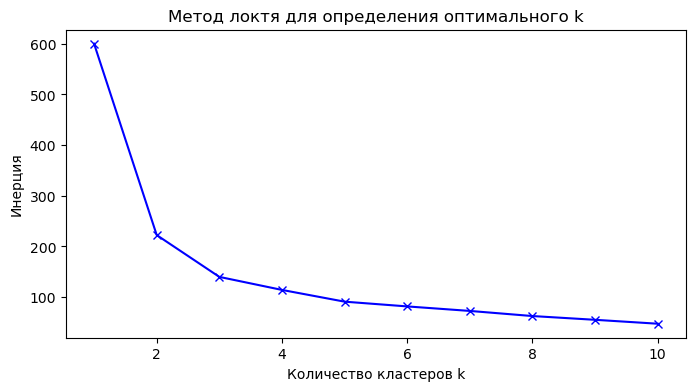

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [2]:
from sklearn.cluster import KMeans

# 1. Метод «Локтя» для поиска оптимального k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Количество кластеров k')
plt.ylabel('Инерция')
plt.title('Метод локтя для определения оптимального k')
plt.show()

# 2. Окончательная кластеризация (например, на 3 кластера)
final_kmeans = KMeans(n_clusters=3, random_state=42)
clusters = final_kmeans.fit_predict(X_scaled)

# Добавляем результаты в таблицу
X['Cluster'] = clusters
print(X.head())

--- Обработка временных рядов ---


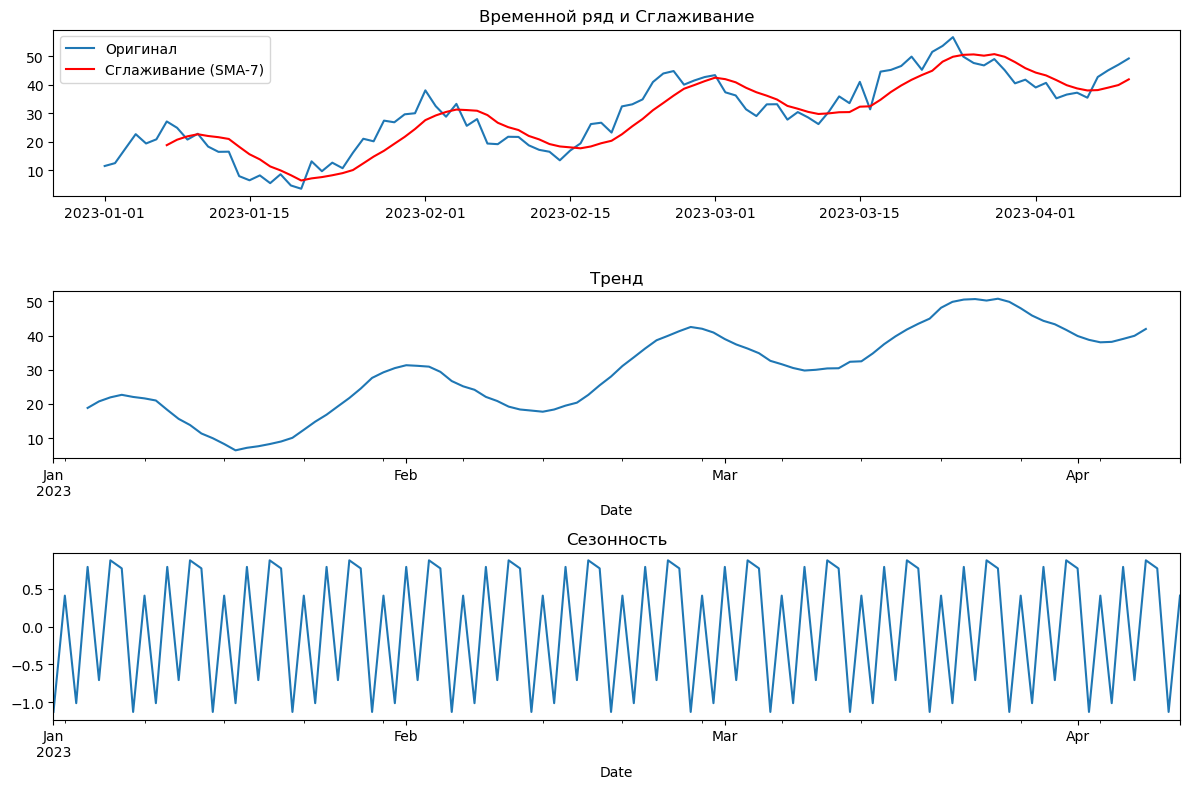


--- Машинное обучение: k-NN и k-Means ---
Точность k-NN:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.67      0.62      0.64        13
           2       0.64      0.69      0.67        13

    accuracy                           0.80        45
   macro avg       0.77      0.77      0.77        45
weighted avg       0.80      0.80      0.80        45



C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


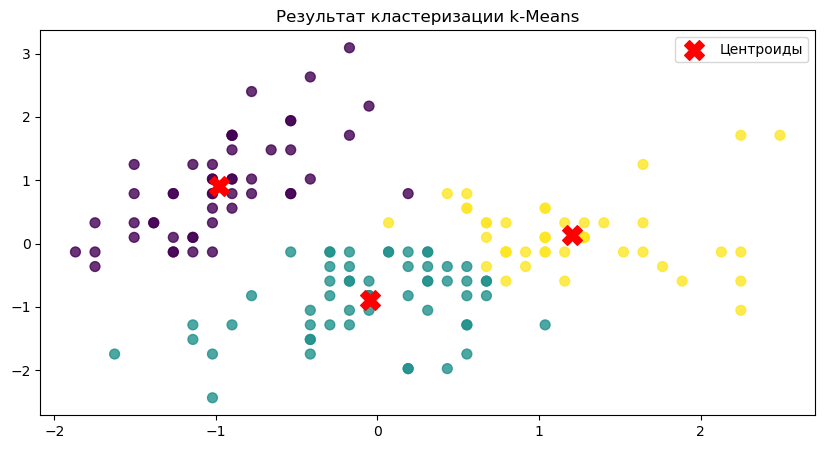

C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\clust

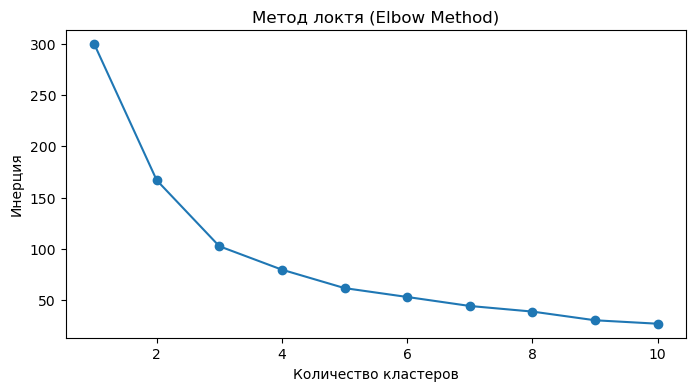

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ==========================================
# БЛОК 1: ВРЕМЕННЫЕ РЯДЫ (Тема 1.12)
# ==========================================
print("--- Обработка временных рядов ---")

# 1. Генерация данных: Тренд + Сезонность + Шум
np.random.seed(42)
time = pd.date_range(start='2023-01-01', periods=100, freq='D')
trend = np.linspace(10, 50, 100)
seasonality = 10 * np.sin(np.linspace(0, 8 * np.pi, 100))
noise = np.random.normal(0, 3, 100)
series = trend + seasonality + noise

df_ts = pd.DataFrame({'Date': time, 'Value': series}).set_index('Date')

# 2. Сглаживание (Скользящее среднее)
df_ts['SMA_7'] = df_ts['Value'].rolling(window=7).mean()

# 3. Декомпозиция
decomp = seasonal_decompose(df_ts['Value'], model='additive', period=7)

# Визуализация временного ряда
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(df_ts['Value'], label='Оригинал')
plt.plot(df_ts['SMA_7'], label='Сглаживание (SMA-7)', color='red')
plt.legend()
plt.title('Временной ряд и Сглаживание')

plt.subplot(3, 1, 2)
decomp.trend.plot(title='Тренд')
plt.subplot(3, 1, 3)
decomp.seasonal.plot(title='Сезонность')
plt.tight_layout()
plt.show()

# ==========================================
# БЛОК 2: МАШИННОЕ ОБУЧЕНИЕ (Тема 1.13)
# ==========================================
print("\n--- Машинное обучение: k-NN и k-Means ---")

# 1. Подготовка данных (используем встроенные ирисы)
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data[:, :2] # Берем два признака для наглядности
y = iris.target

# ОБЯЗАТЕЛЬНО: Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Классификация (k-NN) ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Точность k-NN:\n", classification_report(y_test, y_pred))

# --- Кластеризация (k-Means) ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Визуализация кластеров
plt.figure(figsize=(10, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Центроиды')
plt.title('Результат кластеризации k-Means')
plt.legend()
plt.show()

# --- Метод локтя для СРСП ---
distortions = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    distortions.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), distortions, marker='o')
plt.title('Метод локтя (Elbow Method)')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.show()

C:\Users\Yerbol Aldanov\AppData\Local\Temp\ipykernel_5336\332443174.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='2023-01-01', periods=120, freq='M')


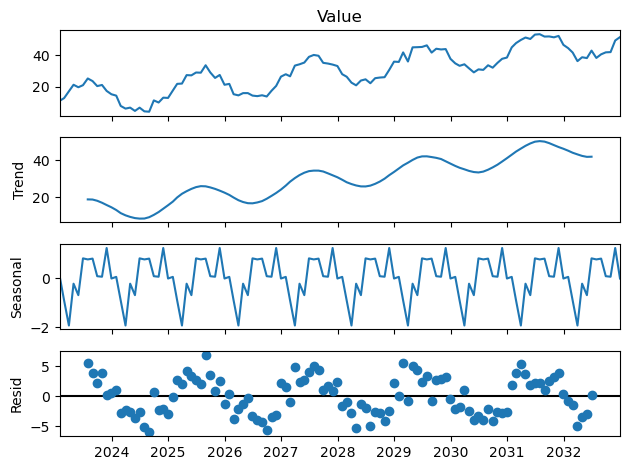

C:\Users\Yerbol Aldanov\.conda\envs\pymc_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Силуэтный коэффициент (для 4 кластеров): 0.657


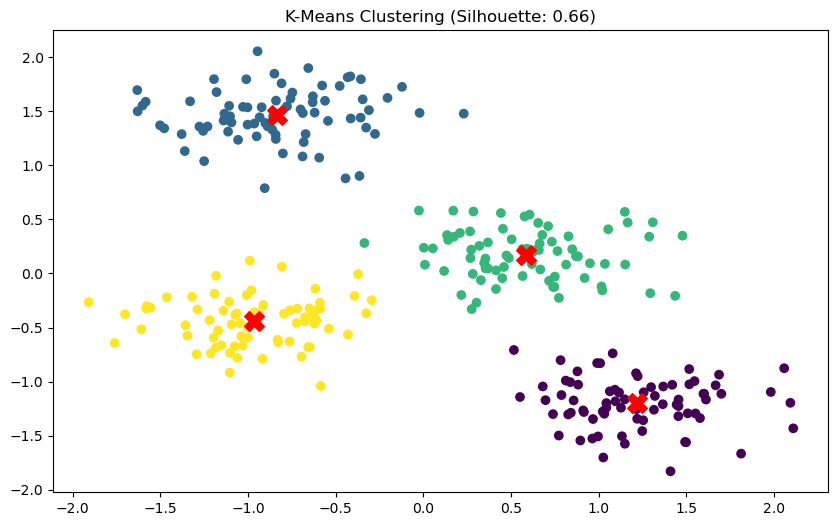


Отчет по k-NN классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.83      0.91      0.87        11
           2       0.92      0.85      0.88        13

    accuracy                           0.90        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.90      0.90      0.90        30



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, silhouette_score # Добавили метрику силуэта

# ==========================================
# 1. ВРЕМЕННЫЕ РЯДЫ (Декомпозиция и Сглаживание)
# ==========================================
np.random.seed(42)
time = pd.date_range(start='2023-01-01', periods=120, freq='M')
series = np.linspace(10, 50, 120) + 10 * np.sin(np.linspace(0, 10 * np.pi, 120)) + np.random.normal(0, 2, 120)
df_ts = pd.DataFrame({'Value': series}, index=time)

# Декомпозиция
decomp = seasonal_decompose(df_ts['Value'], model='additive')
fig_ts = decomp.plot()
fig_ts.savefig('time_series_decomposition.png') # Сохранение
plt.show()

# ==========================================
# 2. КЛАСТЕРИЗАЦИЯ K-Means + СИЛУЭТ (Для СРСП)
# ==========================================
from sklearn.datasets import make_blobs
X_raw, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Оценка силуэта
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, labels)
print(f"Силуэтный коэффициент (для 4 кластеров): {sil_score:.3f}")

# Визуализация и сохранение
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.title(f'K-Means Clustering (Silhouette: {sil_score:.2f})')
plt.savefig('kmeans_clusters.png')
plt.show()

# ==========================================
# 3. КЛАССИФИКАЦИЯ k-NN
# ==========================================
from sklearn.datasets import load_iris
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(scaler.fit_transform(iris.data), iris.target, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print("\nОтчет по k-NN классификации:")
print(classification_report(y_test, knn.predict(X_test)))

In [ ]:
Часть 1: Временные ряды (Тема 1.12)
План выполнения:
Загрузка данных: Импорт CSV/Excel через Pandas, преобразование даты в datetime и установка её в качестве индекса.
Визуализация: Построение исходного графика, чтобы увидеть общую картину.
Сглаживание: Применение метода скользящего среднего (rolling().mean()) для удаления мелких колебаний (шума).
Декомпозиция: Разложение ряда на Тренд, Сезонность и Остатки через seasonal_decompose.


In [ ]:
Часть 2: Машинное обучение (Тема 1.13)
План выполнения:
Предобработка: Обязательная стандартизация признаков через StandardScaler.
Классификация (k-NN):
Разделение данных на Train/Test (80/20).
Обучение модели KNeighborsClassifier.
Вывод метрик (Accuracy, Precision, Recall).
Кластеризация (k-Means) — СРСП:
Запуск алгоритма для разного количества кластеров (
 от 1 до 10).
Построение «Графика локтя» для выбора оптимального 
.
Расчет Силуэтного коэффициента для оценки качества разбиения.

In [ ]:
Подготовить отчет, содержащий 4 ключевых графика:
Декомпозиция временного ряда (4 подграфика).
График предсказаний k-NN (или матрица ошибок).
Метод «Локтя» для кластеризации.
Визуализация полученных кластеров с их центроидами.
Сравнить результаты: указать точность (Accuracy) для классификации и Силуэтный коэффициент для кластеров.
